# This noebook focuses on the pre-processing of Sentinel-1 and Sentinel-2 data

In [ ]:
import zipfile
import os
import rasterio
from rasterio.enums import Resampling
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import pandas as pd



In [ ]:
from google.colab import  drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Since all the files are in zip folders we need to unzip it

# Unzip for Sentinel 2

Sentinel2 = "/content/drive/MyDrive/Deforestation_Project/data/S2/raw"
extracted = os.path.join(Sentinel2, "extracted")
os.makedirs(extracted, exist_ok=True)

In [ ]:


for scenes in os.listdir(Sentinel2):
  if scenes.endswith(".zip"):
    if os.path.exists(os.path.join(extracted, scenes.replace('.zip', ''))):
      print(scenes, "already extracted")
      continue

    with zipfile.ZipFile((os.path.join(Sentinel2, scenes)), "r") as zip_ref:
      zip_ref.extractall(extracted)
    print(f"File {scenes} extracted")

    # break     # just to check for 1 file
print("All Sentinel 2 files extracted")




S2A_MSIL2A_20230326T142711_N0510_R053_T20LNN_20240826T091017.SAFE.zip already extracted
File S2B_MSIL2A_20230328T141719_N0510_R010_T20LNN_20240830T005625.SAFE.zip extracted
File S2B_MSIL2A_20230206T141709_N0510_R010_T20LNN_20240815T024904.SAFE.zip extracted
File S2B_MSIL2A_20230301T142709_N0510_R053_T20LNN_20240817T121956.SAFE.zip extracted
File S2B_MSIL2A_20230226T141709_N0510_R010_T20LNN_20240818T192152.SAFE.zip extracted
File S2B_MSIL2A_20230828T142719_N0510_R053_T20LNN_20241019T002816.SAFE.zip extracted
File S2B_MSIL2A_20230818T142719_N0510_R053_T20LNN_20241025T214836.SAFE.zip extracted
File S2B_MSIL2A_20230726T141719_N0510_R010_T20LNN_20240929T133606.SAFE.zip extracted
File S2B_MSIL2A_20230917T142719_N0510_R053_T20LNN_20241027T080145.SAFE.zip extracted
File S2A_MSIL2A_20230922T142711_N0510_R053_T20LNN_20241026T093629.SAFE.zip extracted
File S2A_MSIL2A_20230714T142721_N0510_R053_T20LNN_20240913T150750.SAFE.zip extracted
File S2A_MSIL2A_20230704T142721_N0510_R053_T20LNN_20240912T134

# Below is the indices calculation from Sentinel 2

In [ ]:
files = []
out_s2 = "/content/drive/MyDrive/Deforestation_Project/data/S2/processed"

In [ ]:

for scenes in os.listdir(extracted):
  if scenes.endswith('.SAFE'):
    date = scenes[11:19]
    name = f"{date}_indices.tif"
    out_path = os.path.join(out_s2, name)

    if os.path.exists(out_path):
      print(f"File {scenes} already processed")
      continue

    else:
      print(f"Starting processing {name.replace('.tif', '')}")
      files.append(scenes)
      search_b04 = glob.glob(os.path.join(extracted, scenes, '**/*_B04_10m.jp2'), recursive=True)
      search_b08 = glob.glob(os.path.join(extracted, scenes, '**/*_B08_10m.jp2'), recursive=True)
      search_b11 = glob.glob(os.path.join(extracted, scenes, '**/*_B11_20m.jp2'), recursive=True)
      search_b12 = glob.glob(os.path.join(extracted, scenes, '**/*_B12_20m.jp2'), recursive=True)
      search_scl = glob.glob(os.path.join(extracted, scenes, '**/*_SCL_20m.jp2'), recursive=True)
      # print(search_b04[0], '\n' , search_b08[0], '\n', search_b11[0], '\n', search_b12[0], '\n', search_scl[0])

      with rasterio.open(search_scl[0]) as src:
        scl = src.read(1, out_shape=(10980, 10980), resampling=Resampling.nearest).astype('float32')      # nearest neighbout interpolation
        profile = src.profile
        # print(scl.shape)
        # print(profile)
      valid_masks = (scl == 4) | (scl == 5) | (scl == 6)          # 4 =vegetataion, 5 = bare soil, 6 = water
      # print("Total no. of valid pixels:", valid_masks.sum())

      with rasterio.open(search_b04[0]) as src:
        b04 = src.read(1).astype('float32')
        b04_masked = np.where(valid_masks, b04, np.nan)
        # print(np.isnan(b04_masked).sum())
        out_profile = src.profile                                 # profile of b04 is chosen since its one of 10 m resolution and the out meta data should be 10m res
        # print(b04.shape)
        # print(profile)

      with rasterio.open(search_b08[0]) as src:
        b08 = src.read(1).astype('float32')
        b08_masked = np.where(valid_masks, b08, np.nan)
        # print(np.isnan(b08_masked).sum())
        profile = src.profile
        # print(b08.shape)
        # print(profile)

      with rasterio.open(search_b11[0]) as src:
        b11 = src.read(1, out_shape=(10980, 10980), resampling=Resampling.bilinear).astype('float32')    # bilinear interpolation
        b11_masked = np.where(valid_masks, b11, np.nan)
        # print(np.isnan(b11_masked).sum())
        profile = src.profile
        # print(b11.shape)
        # print(profile)

      with rasterio.open(search_b12[0]) as src:
        b12 = src.read(1, out_shape=(10980, 10980), resampling=Resampling.bilinear).astype('float32')
        b12_masked = np.where(valid_masks, b12, np.nan)
        # print(np.isnan(b12_masked).sum())
        profile = src.profile
        # print(b12.shape)
        # print(profile)
      with warnings.catch_warnings():
        warnings.simplefilter("ignore")                                  # for not crashing when divison by zero
        NDVI = (b08_masked - b04_masked) / (b08_masked + b04_masked)
        NDMI = (b08_masked - b11_masked) / (b08_masked + b11_masked)
        NBR = (b08_masked - b12_masked) / (b08_masked + b12_masked)

      # print("NDVI min:", np.nanmin(NDVI))
      # print("NDVI max:", np.nanmax(NDVI))
      # print("NDVI mean:", np.nanmean(NDVI))

      out_profile['dtype'] = 'float32'
      out_profile['count'] = 3
      out_profile['nodata'] = np.nan
      out_profile['driver'] = 'GTiff'



      with rasterio.open(out_path, 'w', **out_profile) as dst:
        dst.write(NDVI, 1)
        dst.write(NDMI, 2)
        dst.write(NBR, 3)
    print(f"File {scenes} processed")
print("All Sentinel 2 files processed")

Starting processing 20230326_indices
File S2A_MSIL2A_20230326T142711_N0510_R053_T20LNN_20240826T091017.SAFE processed
Starting processing 20230328_indices
File S2B_MSIL2A_20230328T141719_N0510_R010_T20LNN_20240830T005625.SAFE processed
Starting processing 20230206_indices
File S2B_MSIL2A_20230206T141709_N0510_R010_T20LNN_20240815T024904.SAFE processed
Starting processing 20230301_indices
File S2B_MSIL2A_20230301T142709_N0510_R053_T20LNN_20240817T121956.SAFE processed
Starting processing 20230226_indices
File S2B_MSIL2A_20230226T141709_N0510_R010_T20LNN_20240818T192152.SAFE processed
Starting processing 20230828_indices
File S2B_MSIL2A_20230828T142719_N0510_R053_T20LNN_20241019T002816.SAFE processed
Starting processing 20230818_indices
File S2B_MSIL2A_20230818T142719_N0510_R053_T20LNN_20241025T214836.SAFE processed
Starting processing 20230726_indices
File S2B_MSIL2A_20230726T141719_N0510_R010_T20LNN_20240929T133606.SAFE processed
Starting processing 20230917_indices
File S2B_MSIL2A_202

In [ ]:

Sentinel1 = "/content/drive/MyDrive/Deforestation_Project/data/S1/raw"
extracted_s1 = os.path.join(Sentinel1, "extracted")
os.makedirs(extracted_s1, exist_ok=True)

In [ ]:
# Unzip for Sentinel 1


for scenes in os.listdir(Sentinel1):
  if scenes.endswith(".zip"):
    if os.path.exists(os.path.join(extracted_s1, scenes.replace('.zip', ''))):
      print(scenes, "already extracted")
      continue
    try:
      with zipfile.ZipFile((os.path.join(Sentinel1, scenes)), "r") as zip_ref:
        zip_ref.extractall(extracted_s1)
      print(f"File {scenes} extracted")
    except zipfile.BadZipFile:
      print(f"File {scenes} is not a valid zip file")
      continue

    #break     # just to check for 1 file
print("All Sentinel 1 files extracted")

File S1A_IW_GRDH_1SDV_20230504T094203_20230504T094228_048382_05D1BE_8EBE.SAFE.zip is not a valid zip file
File S1A_IW_GRDH_1SDV_20230708T095005_20230708T095030_049330_05EE9A_9CD7.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20230214T095000_20230214T095025_047230_05AAD4_013E.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20230415T095001_20230415T095026_048105_05C876_4543.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20230801T095006_20230801T095031_049680_05F959_0CC1.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20230901T094210_20230901T094235_050132_060889_0A18.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20230925T094211_20230925T094236_050482_061475_5E63.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20231007T094211_20231007T094236_050657_061A75_A7AA.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20231230T094206_20231230T094231_051882_0644A5_E1D1.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20230310T095000_20230310T095025_047580_05B6BD_4C23.SAFE.zip extracted
File S1A_IW_GRDH_1SDV_20230305T094202_20230305T094227_047507_05B44

## Pre-processing of Sentinel-1 was done through SNAP - SeNtinal Application Platform.

The Graph builder used for the preprocessing is shown below
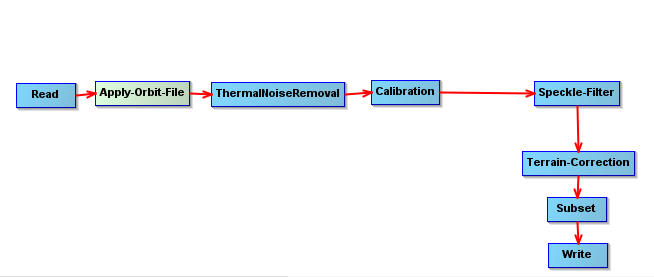
## #Due to unknown reasons the normalized radar backscatter coefficient(Sigma0) was not being saved in decibel scale(dB) in SNAP. So that is done below

$$
\sigma^{0}_{dB} = 10 \log_{10}(\sigma^{0})
$$

In [ ]:
S1_processed = "/content/drive/MyDrive/Deforestation_Project/data/S1/processed"
s1_final = "/content/drive/MyDrive/Deforestation_Project/data/S1/processed/final"
os.makedirs(s1_final, exist_ok=True)

In [ ]:
for scenes in os.listdir(S1_processed):
  if os.path.exists(os.path.join(s1_final, scenes)):
    print("File already exists")
    continue
  else:
    if scenes.endswith(".tif"):
      print(f"Starting db conversion for{scenes}")

      with rasterio.open(os.path.join(S1_processed, scenes)) as src:
        vh = src.read(1)
        if vh[vh != 0].min() < 0:
            print(f"VH of {scenes} already in dB")
            vh_db = vh
            vh_db[vh == 0] = np.nan
            # just copy file
        else:
            print("Converting to dB")
            vh_db = 10 * np.log10(vh, where=(vh > 0))
            # vh_db = vh if vh[vh !=0 ].min() < 0 else 10 * np.log10(vh, where=(vh > 0))    # above loop in a single line
            vh_db[vh == 0] = np.nan


        vv = src.read(2)
        if vv[vv != 0].min() < 0:
            print(f"VV of {scenes} already in dB")
            vv_db = vv
            vv_db[vv == 0] = np.nan
            # just copy file
        else:
            print("Converting to dB")
            vv_db = 10 * np.log10(vv, where=(vv > 0))
            # vv_db = vv if vv[vv !=0 ].min() < 0 else 10 * np.log10(vv, where=(vv > 0))           # above loop in a single line
            vv_db[vv == 0] = np.nan


        out_profile = src.profile
        out_profile.update(
            dtype="float32",
            count=3,
            nodata = np.nan,
            driver='GTiff'
        )
        with rasterio.open(os.path.join(s1_final, scenes), 'w', **out_profile) as dst:
            dst.write(vh_db.astype('float32'), 1)
            dst.write(vv_db.astype('float32'), 2)
            ratio = vh_db - vv_db
            dst.write(ratio.astype('float32'), 3)

      print(f"Finished db conversion for{scenes}")

print("All done scenes converted")




Starting db conversion forSubset_S1A_IW_GRDH_1SDV_20230410T094202_20230410T094227_048032_05C606_CB33_Orb_NR_Cal_Spk_TC.tif
Converting to dB
Converting to dB


Finished db conversion forSubset_S1A_IW_GRDH_1SDV_20230410T094202_20230410T094227_048032_05C606_CB33_Orb_NR_Cal_Spk_TC.tif
Starting db conversion forSubset_S1A_IW_GRDH_1SDV_20230415T095001_20230415T095026_048105_05C876_4543_Orb_NR_Cal_Spk_TC.tif


Converting to dB
Converting to dB


Finished db conversion forSubset_S1A_IW_GRDH_1SDV_20230415T095001_20230415T095026_048105_05C876_4543_Orb_NR_Cal_Spk_TC.tif
Starting db conversion forSubset_S1A_IW_GRDH_1SDV_20230427T095001_20230427T095026_048280_05CE51_C70F_Orb_NR_Cal_Spk_TC.tif


Converting to dB
Converting to dB


...

Finished db conversion forSubset_S1A_IW_GRDH_1SDV_20230310T095000_20230310T095025_047580_05B6BD_4C23_Orb_NR_Cal_Spk_TC.tif
Starting db conversion forSubset_S1A_IW_GRDH_1SDV_20230317T094201_20230317T094226_047682_05BA37_3C36_Orb_NR_Cal_Spk_TC.tif


Converting to dB
Converting to dB


Finished db conversion forSubset_S1A_IW_GRDH_1SDV_20230317T094201_20230317T094226_047682_05BA37_3C36_Orb_NR_Cal_Spk_TC.tif
Starting db conversion forSubset_S1A_IW_GRDH_1SDV_20230322T095000_20230322T095025_047755_05BCAD_42DF_Orb_NR_Cal_Spk_TC.tif


Converting to dB
Converting to dB


Finished db conversion forSubset_S1A_IW_GRDH_1SDV_20230322T095000_20230322T095025_047755_05BCAD_42DF_Orb_NR_Cal_Spk_TC.tif
All done scenes converted


Sentinel-2 data was downloaded by MGRS tile (T20LNN, 110×110km). Sentinel-1 data was downloaded by bounding box and preprocessed in SNAP with a Subset operator clipping to the study area extent (approx. 80×80km, -62.9 to -62.1 lon, -11.7 to -11.0 lat, EPSG:32720).
To ensure pixel-level alignment for time series fusion, all Sentinel-2 processed files (NDVI, NDMI, NBR) are clipped to match the Sentinel-1 spatial extent. The S1 extent is used as the reference since it represents the actual study area boundary. Both datasets are in UTM Zone 20S (EPSG:32720) at 10m resolution after this step.


In [ ]:
s2_final = "/content/drive/MyDrive/Deforestation_Project/data/S2/processed/s2_final"
os.makedirs(s2_final, exist_ok=True)

In [ ]:
result = [tif for tif in os.listdir(s1_final) if tif.endswith(".tif")]
with rasterio.open(os.path.join(s1_final, result[0])) as src:
    # print(src.profile)
    # print(src.bounds)
    # print(src.crs)
    # print(src.res)

    s1_left = src.bounds.left
    s1_right = src.bounds.right
    s1_bottom = src.bounds.bottom
    s1_top = src.bounds.top
    print(s1_left, s1_right, s1_bottom, s1_top)

    for scenes in  os.listdir(out_s2):
      if scenes.endswith(".tif"):
        if os.path.exists(os.path.join(s2_final, scenes)):
          print(f"{scenes} already clipped")
          continue
        else:
          print(f"Clipping {scenes}")
          with rasterio.open(os.path.join(out_s2, scenes)) as src:
            window = rasterio.windows.from_bounds(s1_left, s1_bottom, s1_right, s1_top, src.transform)
            clipped_profile = src.profile.copy()
            clipped_profile.update(width = window.width, height = window.height, transform = rasterio.windows.transform(window, src.transform))
            with rasterio.open(os.path.join(s2_final, scenes), 'w', **clipped_profile) as dst:
              dst.write(src.read(window=window))
            print(f"{scenes} clipped and saved")

print("All S2 files clipped")


516756.65575139533 598326.6557513953 8706456.45661724 8784016.45661724
Clipping 20230326_indices.tif
20230326_indices.tif clipped and saved
Clipping 20230328_indices.tif
20230328_indices.tif clipped and saved
Clipping 20230206_indices.tif
20230206_indices.tif clipped and saved
Clipping 20230301_indices.tif
20230301_indices.tif clipped and saved
Clipping 20230226_indices.tif
20230226_indices.tif clipped and saved
Clipping 20230828_indices.tif
20230828_indices.tif clipped and saved
Clipping 20230818_indices.tif
20230818_indices.tif clipped and saved
Clipping 20230726_indices.tif
20230726_indices.tif clipped and saved
Clipping 20230917_indices.tif
20230917_indices.tif clipped and saved
Clipping 20230922_indices.tif
20230922_indices.tif clipped and saved
Clipping 20230714_indices.tif
20230714_indices.tif clipped and saved
Clipping 20230704_indices.tif
20230704_indices.tif clipped and saved
Clipping 20230701_indices.tif
20230701_indices.tif clipped and saved
Clipping 20230805_indices.tif
20